# Data Chunking Pipeline — Huawei Ascend RAG

**Objetivo:** Conversao estruturada de manuais tecnicos Huawei (PDF -> Markdown), auditoria de sanidade e diagnostico de chunks, e geracao em lote do dataset final para sistemas de Retrieval-Augmented Generation (RAG).

**Secoes do notebook:**
- **Secao A:** Configuracao do ambiente, dependencias e persistencia (Google Drive / local)
- **Secao B:** Extracao de documentos PDF -> Markdown com pos-processamento de hardware
- **Secao C:** Laboratorio comparativo de estrategias de chunking (recursivo vs cabecalhos vs atomico)
- **Secao D:** Diagnosticos, testes de sanidade e auditoria de qualidade (fragmentacao, orfaos, outliers)
- **Secao E:** Processamento em lote do dataset completo, validacao de schema e serializacao multi-formato

**Hardware alvo:** Ascend 310 AI Processor, Atlas 200 DK (Modelos 3000), DaVinci AI Cores  
**Software stack:** CANN/DDK, ATC/OMG, AscendCL, TE/TVM, AIPP

---
## Secao A: Configuracao do Ambiente e Dependencias
*Setup do runtime Colab (GPU T4/V100), instalacao de bibliotecas para parsing de layout, tokenizacao BPE e splitting de texto.*

In [19]:
# ============================================================================
# Cell A.1 — GPU Hardware Verification
# ============================================================================
import subprocess

def check_gpu() -> bool:
    """Check GPU availability and print hardware summary."""
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
             "--format=csv,noheader"],
            capture_output=True, text=True, timeout=10
        )
        if result.returncode == 0 and result.stdout.strip():
            print("[OK] GPU Detected:")
            print(result.stdout.strip())
            return True
    except (FileNotFoundError, subprocess.TimeoutExpired):
        pass
    print("[WARNING] No GPU detected — running on CPU (marker-pdf will be slower)")
    return False

HAS_GPU = check_gpu()

[OK] GPU Detected:
Tesla T4, 15360 MiB, 580.82.07


### Instalacao de Dependencias

Instalacao das bibliotecas principais:
- **`marker-pdf`** — extracao *layout-aware* de PDFs, preservando tabelas pipe de Markdown e hierarquia de cabecalhos em documentos multi-coluna
- **`tiktoken`** — tokenizador BPE (Byte-Pair Encoding) para contagem precisa de tokens
- **`langchain-text-splitters`** — implementacoes de estrategias de *chunking* (recursivo, por cabecalhos Markdown)
- **`tqdm`** — barras de progresso para loops de processamento

In [20]:
# ============================================================================
# Cell A.2 — Dependency Installation
# ============================================================================
%%capture install_output
!pip install -q "marker-pdf[full]" tiktoken langchain-text-splitters tqdm

In [21]:
# ============================================================================
# Cell A.2b — Verify Critical Imports
# ============================================================================
import importlib

print("[INFO] Dependency verification:")
for pkg in ["marker", "tiktoken", "langchain_text_splitters", "tqdm"]:
    spec = importlib.util.find_spec(pkg)
    status = "[OK]" if spec else "[FAIL] MISSING"
    print(f"  {status:<10} {pkg}")

[INFO] Dependency verification:
  [OK]       marker
  [OK]       tiktoken
  [OK]       langchain_text_splitters
  [OK]       tqdm


In [22]:
# ============================================================================
# Cell A.3 — Core Imports
# ============================================================================
import os
import re
import json
import shutil
import zipfile
import textwrap
import warnings
from pathlib import Path
from typing import Optional
from collections import Counter, defaultdict

import tiktoken
from tqdm.auto import tqdm
from IPython.display import display, Markdown as IPyMarkdown, HTML

warnings.filterwarnings("ignore", category=UserWarning)
print("[OK] Core imports loaded")

[OK] Core imports loaded


### Configuracao de Persistencia e Google Drive

O Google Drive e montado **antes** da inicializacao de diretorios para que os PDFs fonte sejam lidos diretamente do Drive.
- `USE_GOOGLE_DRIVE = True` — monta o Drive e sincroniza artefatos automaticamente
- `USE_GOOGLE_DRIVE = False` — opera no armazenamento local do Colab com download via zip

In [23]:
# ============================================================================
# Cell A.4 — Persistence & Google Drive Configuration
# ============================================================================
USE_GOOGLE_DRIVE = True  # Set to True to read PDFs/MDs from Drive and sync outputs
GDRIVE_DEST      = "/content/drive/MyDrive/RAG_Atlas200DK/data/output"

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        try:
            # Standard Colab mount point
            drive.mount("/content/drive")
        except ValueError:
            print("Drive already mounted, continuing...")
        except Exception as e:
            print(f"[INFO] Drive mount status: {e}")
        Path(GDRIVE_DEST).mkdir(parents=True, exist_ok=True)
        print(f"[OK] Google Drive mounted — outputs will sync to: {GDRIVE_DEST}")
    except ImportError:
        print("[INFO] Not running in Google Colab — using local disk persistence")
        USE_GOOGLE_DRIVE = False
else:
    print("[INFO] Local mode — use zip download when ready")


def export_artifact(src_dir: Path, zip_name: str = "processed_markdown.zip"):
    """Pack src_dir into a zip and either download or copy to Drive."""
    zip_path = OUTPUT_DIR / zip_name
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for fp in sorted(src_dir.rglob("*")):
            if fp.is_file() and fp.name != zip_name:
                zf.write(fp, fp.relative_to(src_dir.parent))
    size_kb = zip_path.stat().st_size / 1024
    print(f"[SAVE] Created {zip_path} ({size_kb:.0f} KB)")

    if USE_GOOGLE_DRIVE:
        dest = Path(GDRIVE_DEST) / zip_name
        shutil.copy2(zip_path, dest)
        print(f"[SAVE] Copied to Google Drive: {dest}")
    else:
        try:
            from google.colab import files
            files.download(str(zip_path))
            print("[INFO] Download triggered")
        except ImportError:
            print(f"[INFO] Not in Colab — file available at: {zip_path.resolve()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] Google Drive mounted — outputs will sync to: /content/drive/MyDrive/RAG_Atlas200DK/data/output


In [24]:
# ============================================================================
# Cell A.5 — Directory Structure & Auto-Discovery
# ============================================================================
if USE_GOOGLE_DRIVE:
    BASE_DIR = Path("/content/drive/MyDrive/RAG_Atlas200DK")
else:
    BASE_DIR = Path(".")

RAW_PDF_DIR      = BASE_DIR / "data" / "raw" / "manuals"
PROCESSED_MD_DIR = BASE_DIR / "data" / "processed" / "markdown"
OUTPUT_DIR       = BASE_DIR / "data" / "output"

for d in [RAW_PDF_DIR, PROCESSED_MD_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------------
# Multi-Source Markdown Discovery & Auto-Provisioning
# ----------------------------------------------------------------------------
EXPECTED_DOCS = [
    "ApplicationDevelopmentGuide_MindStudio_.md",
    "ATCToolInstructions.md",
    "Atlas200AIAcceleratorModuleApplicationSoftwareDevelopmentGuide_Models3000_.md",
    "EnvironmentDeploymentGuide.md",
    "Huawei_Atlas_200_DK_developer_kit_Technical_White_Paper__Model_3000__08.md",
    "MindStudioInstallationGuideUbuntuX86.md",
    "TBECustomOperatorDevelopmentGuide_CLI_.md",
    "TensorFlowNetworkModelPortingandTrainingGuide.md",
    "UserGuide2020.md",
    "UserGuide2021.md",
]


def ensure_markdown_dataset(target_dir: Path) -> list:
    """
    Ensure all 10 processed Markdown manuals are available in target_dir.
    Searches across Google Drive, local Colab disk, zip archives, and
    synchronizes or downloads them if necessary.
    """
    existing = sorted([f for f in target_dir.glob("*.md") if f.is_file()])
    if len(existing) >= 10:
        return existing

    print(f"[INFO] Looking for Markdown manuals (currently {len(existing)} in {target_dir})...")

    # 1. Search candidate directories on local disk and Drive
    search_dirs = [
        Path("./data/processed/markdown"),
        Path("/content/RAG_Atlas200DK/data/processed/markdown"),
        Path("/content/data/processed/markdown"),
        Path("/content/drive/MyDrive/RAG_Atlas200DK/data/processed/markdown"),
        Path("/content/drive/MyDrive/data/processed/markdown"),
        Path("/content/drive/MyDrive/processed/markdown"),
        Path("/content/drive/MyDrive/markdown"),
        Path("/content/processed/markdown"),
        Path("/content/markdown"),
    ]
    for sdir in search_dirs:
        if sdir.resolve() != target_dir.resolve() and sdir.exists():
            found_mds = list(sdir.glob("*.md"))
            if found_mds:
                print(f"[INFO] Discovered {len(found_mds)} Markdown files in {sdir}! Syncing to {target_dir}...")
                for f in found_mds:
                    shutil.copy2(f, target_dir / f.name)
                break

    # 2. Check for zip archives (e.g. processed_markdown.zip)
    existing = sorted([f for f in target_dir.glob("*.md") if f.is_file()])
    if len(existing) < 10:
        zip_candidates = [
            BASE_DIR / "data" / "output" / "processed_markdown.zip",
            BASE_DIR / "output" / "processed_markdown.zip",
            Path("/content/drive/MyDrive/RAG_Atlas200DK/output/processed_markdown.zip"),
            Path("/content/drive/MyDrive/processed_markdown.zip"),
            Path("/content/processed_markdown.zip"),
            Path("./processed_markdown.zip"),
        ]
        for zpath in zip_candidates:
            if zpath.exists() and zipfile.is_zipfile(zpath):
                print(f"[INFO] Extracting Markdown manuals from archive: {zpath}")
                with zipfile.ZipFile(zpath, "r") as zf:
                    for member in zf.namelist():
                        if member.lower().endswith(".md"):
                            fname = Path(member).name
                            target_file = target_dir / fname
                            with zf.open(member) as sf, open(target_file, "wb") as df:
                                shutil.copyfileobj(sf, df)
                break

    # 3. Shallow search in Google Drive for custom upload folders
    existing = sorted([f for f in target_dir.glob("*.md") if f.is_file()])
    if len(existing) < 10 and USE_GOOGLE_DRIVE:
        try:
            drive_root = Path("/content/drive/MyDrive")
            if drive_root.exists():
                for root, dirs, files in os.walk(str(drive_root)):
                    rel_depth = Path(root).relative_to(drive_root).parts
                    if len(rel_depth) > 3:
                        dirs.clear()
                        continue
                    if any("ATCToolInstructions" in f for f in files):
                        src_path = Path(root)
                        print(f"[INFO] Located Markdown manuals in Google Drive: {src_path}")
                        for f in files:
                            if f.endswith(".md"):
                                shutil.copy2(src_path / f, target_dir / f)
                        break
        except Exception:
            pass

    # 4. Fallback: Auto-fetch from public GitHub repository
    existing = sorted([f for f in target_dir.glob("*.md") if f.is_file()])
    if len(existing) < 10:
        print("[INFO] Fetching processed Markdown manuals from GitHub repository...")
        import urllib.request
        base_url = "https://raw.githubusercontent.com/ramonvfs/RAG_Atlas200DK/master/data/processed/markdown/"
        for fname in EXPECTED_DOCS:
            dest_file = target_dir / fname
            if not dest_file.exists():
                try:
                    url = base_url + urllib.request.quote(fname)
                    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
                    with urllib.request.urlopen(req) as resp, open(dest_file, "wb") as out_f:
                        out_f.write(resp.read())
                    print(f"  [DOWNLOADED] {fname}")
                except Exception as e:
                    print(f"  [WARNING] Could not fetch {fname}: {e}")

    return sorted([f for f in target_dir.glob("*.md") if f.is_file()])


md_files = ensure_markdown_dataset(PROCESSED_MD_DIR)
pdf_files = sorted([f for f in RAW_PDF_DIR.iterdir() if f.is_file() and f.suffix.lower() == ".pdf"])

print(f"\n[INFO] Directory status:")
print(f"   - RAW_PDF_DIR:      {RAW_PDF_DIR} ({len(pdf_files)} PDFs)")
print(f"   - PROCESSED_MD_DIR: {PROCESSED_MD_DIR} ({len(md_files)} Markdown manuals)")
print(f"   - OUTPUT_DIR:       {OUTPUT_DIR}")
print(f"\n[OK] Available Markdown manuals ({len(md_files)} files):")
for f in md_files:
    print(f"   - {f.name} ({f.stat().st_size / 1024:.0f} KB)")


[INFO] Directory status:
   - RAW_PDF_DIR:      /content/drive/MyDrive/RAG_Atlas200DK/data/raw/manuals (10 PDFs)
   - PROCESSED_MD_DIR: /content/drive/MyDrive/RAG_Atlas200DK/data/processed/markdown (10 Markdown manuals)
   - OUTPUT_DIR:       /content/drive/MyDrive/RAG_Atlas200DK/data/output

[OK] Available Markdown manuals (10 files):
   - ATCToolInstructions.md (157 KB)
   - ApplicationDevelopmentGuide_MindStudio_.md (106 KB)
   - Atlas200AIAcceleratorModuleApplicationSoftwareDevelopmentGuide_Models3000_.md (1038 KB)
   - EnvironmentDeploymentGuide.md (115 KB)
   - Huawei_Atlas_200_DK_developer_kit_Technical_White_Paper__Model_3000__08.md (26 KB)
   - MindStudioInstallationGuideUbuntuX86.md (87 KB)
   - TBECustomOperatorDevelopmentGuide_CLI_.md (83 KB)
   - TensorFlowNetworkModelPortingandTrainingGuide.md (345 KB)
   - UserGuide2020.md (78 KB)
   - UserGuide2021.md (115 KB)


In [25]:
import os

base_path = str(BASE_DIR)
print(f"Analyzing contents of: {base_path}\n")

if not os.path.exists(base_path):
    print(f"[WARNING] Main folder not found at: {base_path}")
    if os.path.exists("/content/drive"):
        print("\nSearching for RAG_Atlas200DK across Google Drive:")
        for root, dirs, files in os.walk("/content/drive"):
            if "RAG_Atlas200DK" in dirs or "RAG_Atlas200DK" in os.path.basename(root):
                print(f"  Found candidate folder: {root}")
else:
    for root, dirs, files in os.walk(base_path):
        dirs[:] = [d for d in dirs if not d.startswith(".")]
        level = root.replace(base_path, "").count(os.sep)
        indent = " " * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = " " * 4 * (level + 1)
        for f in files:
            size_kb = os.path.getsize(os.path.join(root, f)) / 1024
            print(f"{subindent}{f} ({size_kb:.0f} KB)")

Analyzing contents of: /content/drive/MyDrive/RAG_Atlas200DK

RAG_Atlas200DK/
    data_chunking.ipynb (103 KB)
    data/
        raw/
            manuals/
                ATCToolInstructions.pdf (1278 KB)
                ApplicationDevelopmentGuide(MindStudio).pdf (964 KB)
                Atlas200AIAcceleratorModuleApplicationSoftwareDevelopmentGuide(Models3000) .pdf (5329 KB)
                EnvironmentDeploymentGuide.pdf (4726 KB)
                Huawei Atlas 200 DK developer kit Technical White Paper (Model 3000) 08.pdf (2037 KB)
                MindStudioInstallationGuideUbuntuX86.pdf (1075 KB)
                TBECustomOperatorDevelopmentGuide(CLI).pdf (652 KB)
                TensorFlowNetworkModelPortingandTrainingGuide.pdf (2353 KB)
                UserGuide2020.pdf (1672 KB)
                UserGuide2021.pdf (4554 KB)
        processed/
            markdown/
                ATCToolInstructions.md (157 KB)
                ApplicationDevelopmentGuide_MindStudio_.md (106 KB)
     

In [26]:
# ============================================================================
# Cell A.6 — Tokenizer Configuration
# ============================================================================
TIKTOKEN_ENCODING = "cl100k_base"
enc = tiktoken.get_encoding(TIKTOKEN_ENCODING)


def count_tokens(text: str) -> int:
    """Count BPE tokens using tiktoken."""
    return len(enc.encode(text))


# Quick validation
_test_count = count_tokens("Hello, Ascend 310 AI Processor with DaVinci cores!")
assert _test_count > 0, "Tokenizer returned 0 tokens"
print(f"[OK] Tokenizer ready: {TIKTOKEN_ENCODING} (test: {_test_count} tokens)")

[OK] Tokenizer ready: cl100k_base (test: 14 tokens)


---
## Secao B: Extracao de Documentos PDF -> Markdown

*Parsing layout-aware dos manuais tecnicos Huawei usando `marker-pdf` com pipeline de pos-processamento para:*
- **Remocao de cabecalhos/rodapes** recorrentes (ex.: "Huawei Proprietary", banners de capitulo)
- **Correcao de hifenizacao** em termos tecnicos quebrados entre linhas (ex.: `DaV-inci` -> `DaVinci`)
- **Normalizacao de unidades** de hardware (`TFLOPS`, `TOPS`, `GB/s`, `mA`, `V`)

In [27]:
# ============================================================================
# Cell B.1 — Post-Processing Pipeline for Huawei Manuals
# ============================================================================

# Huawei proprietary footers / headers to strip
_HEADER_FOOTER_PATTERNS = [
    re.compile(r"(?im)^.*Huawei\s+Proprietary.*$"),
    re.compile(r"(?im)^.*Huawei\s+Confidential.*$"),
    re.compile(r"(?im)^.*Huawei\s+Technologies\s+Co\.?,?\s*Ltd\.?.*$"),
    re.compile(r"(?im)^\s*Issue\s+\d+.*Date.*$"),
    re.compile(r"(?im)^\s*Copyright\s+©.*Huawei.*$"),
    re.compile(r"(?im)^\s*Page\s+\d+\s*$"),
    re.compile(r"(?im)^\s*\d+\s*$"),  # bare page numbers
]

# Technical terms commonly broken by PDF line wraps
_HYPHEN_REJOINS = [
    (re.compile(r"DaV-\s*inci", re.I), "DaVinci"),
    (re.compile(r"NC1HW-\s*C0", re.I), "NC1HWC0"),
    (re.compile(r"conv2-\s*d", re.I), "conv2d"),
    (re.compile(r"Ascend-\s*CL", re.I), "AscendCL"),
    (re.compile(r"Mind-\s*Studio", re.I), "MindStudio"),
    (re.compile(r"Tensor-\s*Flow", re.I), "TensorFlow"),
    (re.compile(r"FRACTAL-\s*Z", re.I), "FRACTAL_Z"),
    (re.compile(r"LPDDR-?\s*4X", re.I), "LPDDR4X"),
    # Generic: rejoin word-hyphen-newline-word
    (re.compile(r"(\w)-\n(\w)"), r"\1\2"),
]

# Unit normalization: ensure consistent spacing/casing
_UNIT_NORMALIZATIONS = [
    (re.compile(r"(?<!\w)(T\s*F\s*L\s*O\s*P\s*S)(?!\w)", re.I), "TFLOPS"),
    (re.compile(r"(?<!\w)(T\s*O\s*P\s*S)(?!\w)", re.I), "TOPS"),
    (re.compile(r"(\d)\s*(GB\s*/\s*s)", re.I), r"\1 GB/s"),
    (re.compile(r"(\d)\s*(mA)(?!\w)", re.I), r"\1 mA"),
    (re.compile(r"(\d)\s*([VW])(?!\w)"), r"\1 \2"),
]


def postprocess_markdown(text: str) -> str:
    """Apply Huawei-specific post-processing to extracted Markdown."""
    # Strip headers/footers
    for pat in _HEADER_FOOTER_PATTERNS:
        text = pat.sub("", text)

    # Fix broken technical terms
    for pat, repl in _HYPHEN_REJOINS:
        text = pat.sub(repl, text)

    # Normalize hardware units
    for pat, repl in _UNIT_NORMALIZATIONS:
        text = pat.sub(repl, text)

    # Collapse excessive blank lines
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


# Quick test
_test_in = "DaV-\ninci core at 8 T F L O P S\nHuawei Proprietary and Confidential"
_test_out = postprocess_markdown(_test_in)
print("[OK] Post-processing pipeline ready")
print(f'   Test input:  "{_test_in[:50]}..."')
print(f'   Test output: "{_test_out[:60]}..."')

[OK] Post-processing pipeline ready
   Test input:  "DaV-
inci core at 8 T F L O P S
Huawei Proprietary..."
   Test output: "DaVinci core at 8 TFLOPS..."


In [28]:
# ============================================================================
# Cell B.2 — Batch PDF to Markdown Converter
# ============================================================================


def convert_pdfs_to_markdown(
    input_dir: Path,
    output_dir: Path,
    force_convert: bool = False,
) -> dict:
    """
    Convert all PDFs in input_dir to cleaned Markdown files in output_dir.

    If output_dir already contains converted .md files and force_convert=False,
    skips conversion and loads the existing documents directly.
    """
    # 1. Check for existing processed Markdown files
    existing_mds = sorted([
        f for f in output_dir.iterdir()
        if f.is_file() and f.suffix.lower() == ".md"
    ]) if output_dir.exists() else []

    if not existing_mds and "ensure_markdown_dataset" in globals():
        existing_mds = ensure_markdown_dataset(output_dir)

    if existing_mds and not force_convert:
        print(f"[INFO] Found {len(existing_mds)} existing Markdown files in {output_dir}")
        print("[INFO] Skipping PDF conversion. Loading existing processed documents...\n")
        results = {}
        for md_path in existing_mds:
            doc_name = md_path.stem.strip()
            text = md_path.read_text(encoding="utf-8")
            tok = count_tokens(text)
            results[doc_name] = {
                "md_path": str(md_path),
                "tokens": tok,
                "chars": len(text),
                "status": "OK",
            }
            print(f"  [OK] {doc_name}: {tok:,} tokens, {len(text):,} chars (loaded from disk)")
        return results

    # 2. Check for PDFs in input_dir
    all_files = list(input_dir.iterdir()) if input_dir.exists() else []
    pdf_files_list = sorted([
        f for f in all_files if f.is_file() and f.suffix.lower() == ".pdf"
    ])
    if not pdf_files_list:
        if existing_mds:
            print(f"[INFO] No PDFs in {input_dir}, but {len(existing_mds)} Markdown manuals exist. Loading existing.")
            results = {}
            for md_path in existing_mds:
                doc_name = md_path.stem.strip()
                text = md_path.read_text(encoding="utf-8")
                tok = count_tokens(text)
                results[doc_name] = {
                    "md_path": str(md_path),
                    "tokens": tok,
                    "chars": len(text),
                    "status": "OK",
                }
            return results
        raise FileNotFoundError(
            f"No PDF files found in {input_dir} and no Markdown files found in {output_dir}."
        )

    from marker.config.parser import ConfigParser
    from marker.models import create_model_dict
    from marker.output import save_output

    print(f"[INFO] Found {len(pdf_files_list)} PDFs to convert")

    cli_options = {
        "output_format": "markdown",
        "disable_ocr": True,
        "disable_image_extraction": True,
        "paginate_output": False,
    }
    config_parser = ConfigParser(cli_options)

    print("[INFO] Initializing marker-pdf models (disable_ocr mode, no Docker)...")
    converter_cls = config_parser.get_converter_cls()
    config_dict = config_parser.generate_config_dict()
    config_dict["pdftext_workers"] = 1

    artifact_dict = create_model_dict()
    converter = converter_cls(
        config=config_dict,
        artifact_dict=artifact_dict,
        processor_list=config_parser.get_processors(),
        renderer=config_parser.get_renderer(),
    )
    print("[OK] Models loaded\n")

    results = {}
    for pdf_path in tqdm(pdf_files_list, desc="Converting PDFs", unit="file"):
        doc_name = pdf_path.stem.strip()
        md_filename = re.sub(r"[^\w\-.]", "_", doc_name) + ".md"
        md_out_path = output_dir / md_filename

        if md_out_path.exists() and not force_convert:
            text = md_out_path.read_text(encoding="utf-8")
            tok = count_tokens(text)
            results[doc_name] = {
                "md_path": str(md_out_path),
                "tokens": tok,
                "chars": len(text),
                "status": "OK",
            }
            print(f"  [OK] {doc_name} already converted, skipping")
            continue

        try:
            rendered = converter(str(pdf_path))
            raw_md = rendered.markdown

            clean_md = postprocess_markdown(raw_md)
            md_out_path.write_text(clean_md, encoding="utf-8")
            token_count = count_tokens(clean_md)

            results[doc_name] = {
                "md_path": str(md_out_path),
                "tokens": token_count,
                "chars": len(clean_md),
                "status": "OK"
            }
            print(f"  [OK] {doc_name}: {token_count:,} tokens, {len(clean_md):,} chars")

        except Exception as e:
            results[doc_name] = {
                "md_path": None,
                "tokens": 0,
                "chars": 0,
                "status": f"FAIL {type(e).__name__}: {e}"
            }
            import traceback; traceback.print_exc()
            print(f"  [FAIL] {doc_name}: {e}")

    return results

### Execucao da Conversao em Lote

*Se os arquivos Markdown ja existirem em `data/processed/markdown/`, a conversao e pulada automaticamente e os documentos sao carregados diretamente do disco. Para forcar uma nova extracao a partir dos PDFs, defina `FORCE_CONVERT = True`.*

In [29]:
# ============================================================================
# Cell B.3 — Execute Batch Conversion
# ============================================================================
FORCE_CONVERT = False  # Set to True to re-convert PDFs even if MDs already exist

existing_md_count = len(list(PROCESSED_MD_DIR.glob("*.md")))
if existing_md_count > 0 and not FORCE_CONVERT:
    print(f"[INFO] Found {existing_md_count} processed Markdown files.")
    print("[INFO] Skipping PDF extraction because Markdown files are already present.")
    print("[INFO] Set FORCE_CONVERT = True if you want to re-run extraction from PDFs.\n")

conversion_results = convert_pdfs_to_markdown(
    RAW_PDF_DIR,
    PROCESSED_MD_DIR,
    force_convert=FORCE_CONVERT,
)

# Summary table
print("\n" + "=" * 72)
print(f"{'Document':<45} {'Tokens':>8}  {'Chars':>8}  Status")
print("=" * 72)
total_tokens = 0
for name, info in sorted(conversion_results.items()):
    total_tokens += info["tokens"]
    print(f"{name[:44]:<45} {info['tokens']:>8,}  {info['chars']:>8,}  {info['status']}")
print("=" * 72)
print(f"{'TOTAL':<45} {total_tokens:>8,}")

[INFO] Found 10 processed Markdown files.
[INFO] Skipping PDF extraction because Markdown files are already present.
[INFO] Set FORCE_CONVERT = True if you want to re-run extraction from PDFs.

[INFO] Found 10 existing Markdown files in /content/drive/MyDrive/RAG_Atlas200DK/data/processed/markdown
[INFO] Skipping PDF conversion. Loading existing processed documents...

  [OK] ATCToolInstructions: 37,719 tokens, 160,478 chars (loaded from disk)
  [OK] ApplicationDevelopmentGuide_MindStudio_: 25,311 tokens, 108,117 chars (loaded from disk)
  [OK] Atlas200AIAcceleratorModuleApplicationSoftwareDevelopmentGuide_Models3000_: 246,233 tokens, 1,060,979 chars (loaded from disk)
  [OK] EnvironmentDeploymentGuide: 30,161 tokens, 117,544 chars (loaded from disk)
  [OK] Huawei_Atlas_200_DK_developer_kit_Technical_White_Paper__Model_3000__08: 6,228 tokens, 26,385 chars (loaded from disk)
  [OK] MindStudioInstallationGuideUbuntuX86: 19,606 tokens, 88,690 chars (loaded from disk)
  [OK] TBECustomOpera

In [30]:
# ============================================================================
# Cell B.4 — Markdown Preview Utility
# ============================================================================

def preview_markdown_sample(md_file_path: str, char_limit: int = 2000):
    """Display raw text and rendered Markdown preview inside Colab/Jupyter."""
    text = Path(md_file_path).read_text(encoding="utf-8")
    sample = text[:char_limit]
    token_count = count_tokens(text)

    print(f"[FILE] File: {Path(md_file_path).name}")
    print(f"   Total: {len(text):,} chars | {token_count:,} tokens")
    print(f"   Showing first {char_limit:,} characters\n")

    # Raw text view
    print("--- Raw Text ---")
    print(sample)
    if len(text) > char_limit:
        print(f"\n... ({len(text) - char_limit:,} more characters)")
    print("-" * 50)

    # Rendered Markdown view
    display(IPyMarkdown(f"**--- Rendered Preview ---**\n\n{sample}"))

In [31]:
# ============================================================================
# Cell B.5 — Preview First Converted Document
# ============================================================================
md_files = sorted(PROCESSED_MD_DIR.glob("*.md"))
if md_files:
    preview_markdown_sample(str(md_files[0]), char_limit=2000)
else:
    print("[WARNING] No Markdown files found — run conversion cell first")

[FILE] File: ATCToolInstructions.md
   Total: 160,478 chars | 37,719 tokens
   Showing first 2,000 characters

--- Raw Text ---
# **Atlas 200 DK V100R020C00 ATC Tool Instructions**

**Issue** 01 **Date** 2021-01-29

# **Trademarks and Permissions**

# **Notice**

The purchased products, services and features are stipulated by the contract made between Huawei and the customer. All or part of the products, services and features described in this document may not be within the purchase scope or the usage scope. Unless otherwise specified in the contract, all statements, information, and recommendations in this document are provided "AS IS" without warranties, guarantees or representations of any kind, either express or implied.

The information in this document is subject to change without notice. Every effort has been made in the preparation of this document to ensure accuracy of the contents, but all statements, information, and recommendations in this document do not constitute a warra

**--- Rendered Preview ---**

# **Atlas 200 DK V100R020C00 ATC Tool Instructions**

**Issue** 01 **Date** 2021-01-29

# **Trademarks and Permissions**

# **Notice**

The purchased products, services and features are stipulated by the contract made between Huawei and the customer. All or part of the products, services and features described in this document may not be within the purchase scope or the usage scope. Unless otherwise specified in the contract, all statements, information, and recommendations in this document are provided "AS IS" without warranties, guarantees or representations of any kind, either express or implied.

The information in this document is subject to change without notice. Every effort has been made in the preparation of this document to ensure accuracy of the contents, but all statements, information, and recommendations in this document do not constitute a warranty of any kind, express or implied.

# **Contents**

| 1 Introduction..............................................................................................................................                                                   | 1   |
|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----|
| 4.1 Overview.................................................................................................................................................................................. | 38  |
| 4.3 CSC Configuration................................................................................................................................................................          | 43  |
| 4.4 Cropping and Padding Configuration............................................................................................................................                             | 60  |
| 5 Single-Operator JSON File Configuration..........................

In [32]:
# ============================================================================
# Cell B.6 — Table Integrity Auditor
# ============================================================================

def audit_table_integrity(md_file_path: str) -> dict:
    """
    Scan a Markdown file for pipe tables and check for truncation/misalignment.

    Detects:
    - Inconsistent column counts within a table block
    - Single-row tables (possible truncation)
    - Missing separator rows (|---|---|)

    Returns:
        dict with 'file', 'tables_found', 'issues', and 'details' keys.
    """
    text = Path(md_file_path).read_text(encoding="utf-8")
    lines = text.split("\n")

    # Detect table blocks: consecutive lines containing pipes
    table_blocks = []
    current_block = []
    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith("|") and "|" in stripped[1:]:
            current_block.append((i + 1, stripped))
        else:
            if current_block:
                table_blocks.append(current_block)
                current_block = []
    if current_block:
        table_blocks.append(current_block)

    issues = []
    for idx, block in enumerate(table_blocks):
        col_counts = [row[1].count("|") for row in block]

        # Check column consistency
        if len(set(col_counts)) > 1:
            issues.append(
                f"Table #{idx+1} (lines {block[0][0]}-{block[-1][0]}): "
                f"inconsistent column counts {sorted(set(col_counts))}"
            )

        # Check for truncated single-row tables
        if len(block) < 2:
            issues.append(
                f"Table #{idx+1} (line {block[0][0]}): "
                f"single-row table — possible truncation"
            )

        # Check for separator row
        has_separator = any(
            re.match(r"^\|[\s\-:|]+\|$", row[1]) for row in block
        )
        if not has_separator and len(block) > 1:
            issues.append(
                f"Table #{idx+1} (lines {block[0][0]}-{block[-1][0]}): "
                f"missing separator row (|---|---|)"
            )

    result = {
        "file": Path(md_file_path).name,
        "tables_found": len(table_blocks),
        "issues": len(issues),
        "details": issues,
    }

    print(f"[STATS] {result['file']}: {result['tables_found']} tables, "
          f"{result['issues']} issues")
    for issue in issues[:10]:
        print(f"   [WARNING] {issue}")

    return result

In [33]:
# ============================================================================
# Cell B.7 — Run Table Integrity Audit on All Converted Files
# ============================================================================
print("[AUDIT] Table Integrity Audit\n")
all_audits = {}
for md_file in sorted(PROCESSED_MD_DIR.glob("*.md")):
    all_audits[md_file.name] = audit_table_integrity(str(md_file))
    print()

total_tables = sum(a["tables_found"] for a in all_audits.values())
total_issues = sum(a["issues"] for a in all_audits.values())
print(f"{'=' * 55}")
print(f"Summary: {total_tables} tables across {len(all_audits)} files, "
      f"{total_issues} issues detected")

[AUDIT] Table Integrity Audit

[STATS] ATCToolInstructions.md: 86 tables, 0 issues

[STATS] ApplicationDevelopmentGuide_MindStudio_.md: 10 tables, 0 issues

[STATS] Atlas200AIAcceleratorModuleApplicationSoftwareDevelopmentGuide_Models3000_.md: 467 tables, 0 issues

[STATS] EnvironmentDeploymentGuide.md: 12 tables, 0 issues

[STATS] Huawei_Atlas_200_DK_developer_kit_Technical_White_Paper__Model_3000__08.md: 15 tables, 0 issues

[STATS] MindStudioInstallationGuideUbuntuX86.md: 13 tables, 0 issues

[STATS] TBECustomOperatorDevelopmentGuide_CLI_.md: 13 tables, 0 issues

[STATS] TensorFlowNetworkModelPortingandTrainingGuide.md: 100 tables, 0 issues

[STATS] UserGuide2020.md: 8 tables, 0 issues

[STATS] UserGuide2021.md: 13 tables, 0 issues

Summary: 737 tables across 10 files, 0 issues detected


In [34]:
# ============================================================================
# Cell B.8 — Export Processed Markdown Artifacts
# ============================================================================

try:
    export_artifact(PROCESSED_MD_DIR, "processed_markdown.zip")
except Exception as e:
    if "are the same file" in str(e):
        print("[INFO] Artifact already stored directly in the destination folder. Skipping redundant copy.")
    else:
        raise e

[SAVE] Created /content/drive/MyDrive/RAG_Atlas200DK/data/output/processed_markdown.zip (444 KB)
[INFO] Artifact already stored directly in the destination folder. Skipping redundant copy.


---
## Secao C: Laboratorio Comparativo de Estrategias de Chunking

*Avaliacao sistematica de tres abordagens de chunking para RAG, aplicadas sobre os documentos Markdown extraidos:*

| # | Estrategia | Descricao |
|---|-----------|----------|
| 1 | **Recursive Window** (baseline) | Splitting recursivo por caracteres com `RecursiveCharacterTextSplitter` |
| 2 | **Markdown Header** (hierarquico) | Splitting por cabecalhos `#`/`##`/`###` com preservacao de hierarquia |
| 3 | **Atomic Table-Aware** (hibrido) | Chunking atomico preservando tabelas intactas + breadcrumbs de contexto |

In [35]:
# ============================================================================
# Cell C.1 — Strategy 1: Fixed/Recursive Window Splitting (Baseline)
# ============================================================================
from langchain_text_splitters import RecursiveCharacterTextSplitter


def strategy_recursive_split(
    text: str,
    chunk_size: int = 1024,
    chunk_overlap: int = 128,
) -> list[dict]:
    """
    Strategy 1: Fixed/recursive window splitting (baseline).

    Uses RecursiveCharacterTextSplitter with tiktoken-based length function.
    Splits preferring paragraph breaks, then line breaks, then sentences.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=count_tokens,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    chunks = splitter.split_text(text)
    return [
        {
            "text": chunk,
            "strategy": "recursive",
            "chunk_index": i,
            "approx_tokens": count_tokens(chunk),
            "metadata": {
                "chunk_size_param": chunk_size,
                "chunk_overlap_param": chunk_overlap,
            }
        }
        for i, chunk in enumerate(chunks)
    ]


print("[OK] Strategy 1 (Recursive Window) defined")

[OK] Strategy 1 (Recursive Window) defined


### Estrategia 2: Splitting por Cabecalhos Markdown

*Preserva a hierarquia de secoes como metadados de cada chunk. Por exemplo, um trecho sob `## Supported Operators > ### Caffe Network Model` carrega essa informacao de escopo. Secoes que excedem o limite de tokens sao subdivididas com `RecursiveCharacterTextSplitter`.*

In [36]:
# ============================================================================
# Cell C.2 — Strategy 2: Markdown Structural / Header Splitting
# ============================================================================
from langchain_text_splitters import MarkdownHeaderTextSplitter


def strategy_markdown_header_split(
    text: str,
    max_chunk_tokens: int = 1024,
) -> list[dict]:
    """
    Strategy 2: Markdown structural / header splitting.

    Splits along header boundaries (#, ##, ###, ####) and preserves the
    header hierarchy as metadata. Oversized sections are sub-split with
    RecursiveCharacterTextSplitter.
    """
    headers_to_split_on = [
        ("#",    "Header_1"),
        ("##",   "Header_2"),
        ("###",  "Header_3"),
        ("####", "Header_4"),
    ]

    md_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=headers_to_split_on,
        strip_headers=False,
    )
    header_chunks = md_splitter.split_text(text)

    # Sub-split oversized sections
    sub_splitter = RecursiveCharacterTextSplitter(
        chunk_size=max_chunk_tokens,
        chunk_overlap=64,
        length_function=count_tokens,
    )
    results = []
    for doc in header_chunks:
        content = doc.page_content
        metadata = dict(doc.metadata)
        header_path = " > ".join(
            v for k, v in sorted(metadata.items())
            if k.startswith("Header_")
        )

        if count_tokens(content) > max_chunk_tokens:
            sub_chunks = sub_splitter.split_text(content)
            for j, sc in enumerate(sub_chunks):
                results.append({
                    "text": sc,
                    "strategy": "markdown_header",
                    "chunk_index": len(results),
                    "approx_tokens": count_tokens(sc),
                    "metadata": {
                        "header_path": header_path,
                        **metadata,
                        "sub_chunk": j,
                    }
                })
        else:
            results.append({
                "text": content,
                "strategy": "markdown_header",
                "chunk_index": len(results),
                "approx_tokens": count_tokens(content),
                "metadata": {
                    "header_path": header_path,
                    **metadata,
                }
            })

    return results


print("[OK] Strategy 2 (Markdown Header) defined")

[OK] Strategy 2 (Markdown Header) defined


### Estrategia 3: Chunking Atomico com Preservacao de Tabelas e Breadcrumbs

*Abordagem hibrida customizada que:*
1. **Detecta blocos atomicos** — tabelas pipe de Markdown e blocos de codigo sao mantidos intactos (sem fragmentacao entre linhas)
2. **Injeta breadcrumbs** — cada chunk recebe um prefixo `[Doc: X > Section: Y > Sub: Z]` com o caminho hierarquico completo
3. **Enriquece metadados** — `doc_name`, `header_path`, `is_table`, `is_code_block`, `approx_tokens`

In [37]:
# ============================================================================
# Cell C.3 — Strategy 3: Atomic Table-Aware & Breadcrumb Hybrid Chunking
# ============================================================================

def strategy_atomic_table_aware(
    text: str,
    doc_name: str = "unknown",
    max_chunk_tokens: int = 1024,
    chunk_overlap: int = 64,
) -> list[dict]:
    """
    Strategy 3: Atomic table-aware chunking with breadcrumb context.

    Pipeline:
    1. Parse the heading hierarchy to build section paths.
    2. Within each section, identify atomic blocks (tables, code fences).
    3. Keep atomic blocks intact; sub-split prose exceeding max_chunk_tokens.
    4. Prepend breadcrumb path to every chunk for standalone readability.

    Returns:
        List of chunk dicts with text, strategy, chunk_index, approx_tokens, metadata.
    """
    lines = text.split("\n")
    sections = []
    current_headers = {}
    current_lines = []
    current_has_table = False

    def _flush_section():
        nonlocal current_lines, current_has_table
        if current_lines:
            path_parts = [
                current_headers[k]
                for k in sorted(current_headers.keys())
            ]
            sections.append((
                " > ".join(path_parts) if path_parts else "Root",
                "\n".join(current_lines),
                current_has_table,
            ))
        current_lines = []
        current_has_table = False

    for line in lines:
        header_match = re.match(r"^(#{1,4})\s+(.+)$", line)
        if header_match:
            _flush_section()
            level = len(header_match.group(1))
            title = header_match.group(2).strip()
            current_headers[level] = title
            for k in list(current_headers.keys()):
                if k > level:
                    del current_headers[k]
            current_lines.append(line)
        else:
            current_lines.append(line)
            if line.strip().startswith("|"):
                current_has_table = True
    _flush_section()

    results = []

    for header_path, section_text, _ in sections:
        breadcrumb = f"[Doc: {doc_name} > {header_path}]"

        parts = re.split(
            r"(```[\s\S]*?```|(?:^\|.+\|$\n?){2,})",
            section_text,
            flags=re.MULTILINE,
        )

        for part in parts:
            part_stripped = part.strip()
            if not part_stripped:
                continue

            is_table = part_stripped.startswith("|")
            is_code = part_stripped.startswith("```")
            is_atomic = is_table or is_code

            chunk_text = f"{breadcrumb}\n\n{part_stripped}"
            tok_count = count_tokens(chunk_text)

            if is_atomic or tok_count <= max_chunk_tokens:
                results.append({
                    "text": chunk_text,
                    "strategy": "atomic_table_aware",
                    "chunk_index": len(results),
                    "approx_tokens": tok_count,
                    "metadata": {
                        "doc_name": doc_name,
                        "header_path": header_path,
                        "is_table": is_table,
                        "is_code_block": is_code,
                    }
                })
            else:
                sub_splitter = RecursiveCharacterTextSplitter(
                    chunk_size=max_chunk_tokens,
                    chunk_overlap=chunk_overlap,
                    length_function=count_tokens,
                )
                for sc in sub_splitter.split_text(part_stripped):
                    sc_with_breadcrumb = f"{breadcrumb}\n\n{sc}"
                    results.append({
                        "text": sc_with_breadcrumb,
                        "strategy": "atomic_table_aware",
                        "chunk_index": len(results),
                        "approx_tokens": count_tokens(sc_with_breadcrumb),
                        "metadata": {
                            "doc_name": doc_name,
                            "header_path": header_path,
                            "is_table": False,
                            "is_code_block": False,
                        }
                    })

    return results


print("[OK] Strategy 3 (Atomic Table-Aware) defined")

[OK] Strategy 3 (Atomic Table-Aware) defined


In [38]:
# ============================================================================
# Cell C.4 — Chunking Strategy Comparison Engine
# ============================================================================

def compare_chunking_strategies(
    sample_md_text: str,
    doc_name: str = "sample",
    chunk_size: int = 1024,
    chunk_overlap: int = 128,
) -> dict:
    """
    Run all three chunking strategies on the same text and compare results.

    Returns:
        dict mapping strategy_name -> {chunks, total_chunks,
        token_min/max/mean/median, table_chunks}
    """
    strategies = {
        "1_recursive": lambda: strategy_recursive_split(
            sample_md_text, chunk_size=chunk_size, chunk_overlap=chunk_overlap
        ),
        "2_markdown_header": lambda: strategy_markdown_header_split(
            sample_md_text, max_chunk_tokens=chunk_size
        ),
        "3_atomic_table_aware": lambda: strategy_atomic_table_aware(
            sample_md_text, doc_name=doc_name,
            max_chunk_tokens=chunk_size, chunk_overlap=chunk_overlap
        ),
    }

    results = {}
    for name, fn in strategies.items():
        chunks = fn()
        token_counts = [c["approx_tokens"] for c in chunks]
        table_chunks = sum(
            1 for c in chunks
            if c.get("metadata", {}).get("is_table", False)
        )

        results[name] = {
            "chunks": chunks,
            "total_chunks": len(chunks),
            "token_min": min(token_counts) if token_counts else 0,
            "token_max": max(token_counts) if token_counts else 0,
            "token_mean": (
                sum(token_counts) / len(token_counts) if token_counts else 0
            ),
            "token_median": (
                sorted(token_counts)[len(token_counts) // 2]
                if token_counts else 0
            ),
            "table_chunks": table_chunks,
        }

    return results


print("[OK] Comparison engine defined")

[OK] Comparison engine defined


In [39]:
# ============================================================================
# Cell C.5 — Comparison Visualization & Reporting
# ============================================================================

def display_comparison_report(results: dict, sample_chunks: int = 2):
    """Display a side-by-side comparison of chunking strategy results."""

    # Summary table
    print("\n" + "=" * 85)
    print(f"{'Strategy':<28} {'Chunks':>7} {'Min':>6} {'Max':>6} "
          f"{'Mean':>7} {'Median':>7} {'Tables':>7}")
    print("=" * 85)
    for name, stats in results.items():
        print(
            f"{name:<28} {stats['total_chunks']:>7} "
            f"{stats['token_min']:>6} {stats['token_max']:>6} "
            f"{stats['token_mean']:>7.0f} {stats['token_median']:>7} "
            f"{stats['table_chunks']:>7}"
        )
    print("=" * 85)

    # Token distributions & sample previews
    for name, stats in results.items():
        print(f"\n[STATS] Token Distribution — {name}")
        print(f"  Count: {stats['total_chunks']} | "
              f"Min: {stats['token_min']} | Max: {stats['token_max']} | "
              f"Mean: {stats['token_mean']:.1f} | Median: {stats['token_median']} | "
              f"Table Chunks: {stats['table_chunks']}")

        print(f"\n[SAMPLE] Sample Chunks — {name}")
        for chunk in stats["chunks"][:sample_chunks]:
            preview = chunk["text"][:400].replace("\n", " ")
            meta = chunk.get("metadata", {})
            print(f"\n  [Chunk #{chunk['chunk_index']}] "
                  f"({chunk['approx_tokens']} tokens)")
            if "header_path" in meta:
                print(f"  Path: {meta['header_path']}")
            if meta.get("is_table"):
                print("  [TABLE] TABLE chunk")
            print(f"  {'.' * 60}")
            print(textwrap.indent(preview, "  "))
            if len(chunk["text"]) > 400:
                print(f"  ... ({len(chunk['text']) - 400} more chars)")


print("[OK] Visualization functions defined")

[OK] Visualization functions defined


### Execucao do Laboratorio Comparativo

*Selecionamos automaticamente um documento que contenha tabelas densas (ex.: `ATCToolInstructions`) para avaliar as tres estrategias em um cenario realista com parametros tecnicos, especificacoes de hardware e listas de operadores.*

In [40]:
# ============================================================================
# Cell C.6 — Run Comparison on a Sample Document
# ============================================================================

# Select a document likely to contain dense parameter tables
_target_keywords = ["ATCToolInstructions", "Atlas200AI", "WhitePaper", "Technical"]
sample_md_path = None

for md_file in sorted(PROCESSED_MD_DIR.glob("*.md")):
    if any(kw.lower() in md_file.stem.lower() for kw in _target_keywords):
        sample_md_path = md_file
        break

# Fallback to first available file
if sample_md_path is None:
    _all_md = sorted(PROCESSED_MD_DIR.glob("*.md"))
    if _all_md:
        sample_md_path = _all_md[0]

if sample_md_path:
    sample_text = sample_md_path.read_text(encoding="utf-8")
    print(f"[FILE] Selected document: {sample_md_path.name}")
    print(f"   Size: {len(sample_text):,} chars | {count_tokens(sample_text):,} tokens\n")

    comparison_results = compare_chunking_strategies(
        sample_text,
        doc_name=sample_md_path.stem,
        chunk_size=1024,
        chunk_overlap=128,
    )
    display_comparison_report(comparison_results, sample_chunks=3)
else:
    print("[WARNING] No Markdown files found — run Section B first")

[FILE] Selected document: ATCToolInstructions.md
   Size: 160,478 chars | 37,719 tokens


Strategy                      Chunks    Min    Max    Mean  Median  Tables
1_recursive                       44    323   1015     914     955       0
2_markdown_header                174      4   1013     223      87       0
3_atomic_table_aware             259     16   1982     176     116      86

[STATS] Token Distribution — 1_recursive
  Count: 44 | Min: 323 | Max: 1015 | Mean: 914.2 | Median: 955 | Table Chunks: 0

[SAMPLE] Sample Chunks — 1_recursive

  [Chunk #0] (955 tokens)
  ............................................................
  # **Atlas 200 DK V100R020C00 ATC Tool Instructions**  **Issue** 01 **Date** 2021-01-29  # **Trademarks and Permissions**  # **Notice**  The purchased products, services and features are stipulated by the contract made between Huawei and the customer. All or part of the products, services and features described in this document may not be within the purcha

### Varredura de Parametros

*Execucao das tres estrategias com diferentes combinacoes de `chunk_size` e `chunk_overlap` para avaliar a sensibilidade dos resultados aos hiperparametros de chunking.*

In [41]:
# ============================================================================
# Cell C.7 — Parameter Sweep Across Chunk Sizes
# ============================================================================
if sample_md_path:
    print("[PARAM SWEEP] Parameter Sweep: chunk_size x chunk_overlap sensitivity\n")

    sweep_summary = []
    for cs in [512, 1024]:
        for co in [64, 128]:
            print(f"{'=' * 65}")
            print(f"  chunk_size={cs}, chunk_overlap={co}")
            print(f"{'=' * 65}")

            r = compare_chunking_strategies(
                sample_text,
                doc_name=sample_md_path.stem,
                chunk_size=cs,
                chunk_overlap=co,
            )

            for sname, stats in r.items():
                row = {
                    "chunk_size": cs,
                    "chunk_overlap": co,
                    "strategy": sname,
                    "n_chunks": stats["total_chunks"],
                    "mean_tokens": round(stats["token_mean"]),
                    "table_chunks": stats["table_chunks"],
                }
                sweep_summary.append(row)
                print(
                    f"    {sname:<28}: {stats['total_chunks']:>4} chunks, "
                    f"mean={stats['token_mean']:.0f} tok, "
                    f"tables={stats['table_chunks']}"
                )
            print()

    # Save sweep results
    sweep_path = OUTPUT_DIR / "parameter_sweep.json"
    sweep_path.write_text(
        json.dumps(sweep_summary, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"\n[SAVE] Sweep results saved to {sweep_path}")
else:
    print("[WARNING] No sample document — run Section B first")

[PARAM SWEEP] Parameter Sweep: chunk_size x chunk_overlap sensitivity

  chunk_size=512, chunk_overlap=64
    1_recursive                 :   96 chunks, mean=417 tok, tables=0
    2_markdown_header           :  204 chunks, mean=197 tok, tables=0
    3_atomic_table_aware        :  272 chunks, mean=177 tok, tables=86

  chunk_size=512, chunk_overlap=128
    1_recursive                 :  101 chunks, mean=430 tok, tables=0
    2_markdown_header           :  204 chunks, mean=197 tok, tables=0
    3_atomic_table_aware        :  272 chunks, mean=179 tok, tables=86

  chunk_size=1024, chunk_overlap=64
    1_recursive                 :   42 chunks, mean=917 tok, tables=0
    2_markdown_header           :  174 chunks, mean=223 tok, tables=0
    3_atomic_table_aware        :  259 chunks, mean=176 tok, tables=86

  chunk_size=1024, chunk_overlap=128
    1_recursive                 :   44 chunks, mean=914 tok, tables=0
    2_markdown_header           :  174 chunks, mean=223 tok, tables=0
    3_ato

---
## Secao D: Diagnosticos, Testes de Sanidade e Auditoria de Qualidade

A qualidade dos *chunks* em um sistema RAG para documentacao de hardware e compiladores e critica para mitigar alucinacoes. Tres patologias comuns degradam severamente a recuperacao:

1. **Fragmentacao de Tabelas (*Table Fragmentation*)**: Tabelas de registradores, flags do compilador ATC e configuracoes AIPP possuem forte correlacao de linhas e colunas. Quando uma tabela e fatiada entre chunks sem preservar o cabecalho (`| --- | --- |`), o modelo perde o mapeamento dos parametros.
2. **Chunks Orfaos (*The Orphan Test*)**: Subsecoes com titulos genericos (ex.: `Overview`, `Parameters`, `Restrictions`) perdem completamente o escopo quando isoladas. Sem o prefixo do documento (`Ascend 310`, `Atlas 200 DK`, `ATC Tool`), a busca densa pode recuperar trechos do framework errado.
3. **Dispersao e Outliers de Tokens**: Micro-chunks (< 30 tokens) representam ruido e fragmentacao excessiva, enquanto blocos inflados (> 1024 tokens) diluem o embedding semantico e estouram a janela de modelos de vetorizacao.

In [42]:
# ============================================================================
# Cell D.2 — Table Fragmentation Audit
# ============================================================================

def check_table_fragmentation(chunks: list[dict]) -> dict:
    """
    Audit a list of chunks to detect severed Markdown tables.

    A chunk is flagged for table fragmentation if:
    1. Severed Start: Begins with a table data row without a preceding header/separator.
    2. Severed End: Ends mid-table with an unclosed row where data continues in another chunk.
    3. Severed Separator: Contains a separator row (| --- | --- |) without its header row.
    4. Sliced Row: A line starts with | but does not end with |, or vice versa.

    Returns:
        dict with total_chunks, table_chunks, fragmented_chunks,
        fragmentation_rate, and sample_fragmented_indices.
    """
    table_separator_pattern = re.compile(r"^\s*\|(?:\s*:?-+:?\s*\|)+\s*$")
    total_chunks = len(chunks)
    table_chunk_count = 0
    fragmented_indices = []

    for idx, chunk in enumerate(chunks):
        text = chunk.get("text", "") or chunk.get("content", "")
        metadata = chunk.get("metadata", {})
        lines = [line.strip() for line in text.split("\n") if line.strip()]

        pipe_lines = [line for line in lines if line.startswith("|") and line.endswith("|")]
        has_table_content = len(pipe_lines) > 0 or metadata.get("is_table", False)

        if not has_table_content:
            continue

        table_chunk_count += 1
        is_fragmented = False

        # Check 1: Malformed pipe row
        for line in lines:
            if (line.startswith("|") and not line.endswith("|")) or (not line.startswith("|") and line.endswith("|") and "|" in line):
                is_fragmented = True
                break

        # Check 2: Severed start
        first_table_line_idx = None
        for i, line in enumerate(lines):
            if line.startswith("[Doc:") or line.startswith("#"):
                continue
            if line.startswith("|") and line.endswith("|"):
                first_table_line_idx = i
                break

        if first_table_line_idx is not None:
            first_line = lines[first_table_line_idx]
            if table_separator_pattern.match(first_line):
                is_fragmented = True
            elif first_table_line_idx + 1 < len(lines):
                second_line = lines[first_table_line_idx + 1]
                if not table_separator_pattern.match(second_line) and not metadata.get("is_table", False):
                    is_fragmented = True
            elif len(pipe_lines) == 1 and not metadata.get("is_table", False):
                is_fragmented = True

        # Check 3: Severed end
        if len(lines) > 0 and lines[-1].startswith("|") and lines[-1].endswith("|"):
            if not metadata.get("is_table", False):
                if first_table_line_idx is not None and not table_separator_pattern.match(lines[-1]):
                    is_fragmented = True

        if is_fragmented:
            fragmented_indices.append(idx)

    frag_rate = (len(fragmented_indices) / table_chunk_count * 100) if table_chunk_count > 0 else 0.0
    return {
        "total_chunks": total_chunks,
        "table_chunks": table_chunk_count,
        "fragmented_chunks": len(fragmented_indices),
        "fragmentation_rate": frag_rate,
        "sample_fragmented_indices": fragmented_indices[:5],
    }


print("[OK] Table fragmentation audit function defined")

# Audit fragmentation across all 3 strategies
if "comparison_results" in dir() and comparison_results:
    print("\n" + "=" * 80)
    print("TABLE FRAGMENTATION AUDIT ACROSS STRATEGIES")
    print("=" * 80)
    print(f"{'Strategy':<25} {'Total':>8} {'Tables':>8} {'Fragmented':>12} {'Frag Rate (%)':>15}")
    print("-" * 80)
    for s_name, res in comparison_results.items():
        audit = check_table_fragmentation(res["chunks"])
        print(f"{s_name:<25} {audit['total_chunks']:>8} {audit['table_chunks']:>8} "
              f"{audit['fragmented_chunks']:>12} {audit['fragmentation_rate']:>14.1f}%")
    print("=" * 80)

[OK] Table fragmentation audit function defined

TABLE FRAGMENTATION AUDIT ACROSS STRATEGIES
Strategy                     Total   Tables   Fragmented   Frag Rate (%)
--------------------------------------------------------------------------------
1_recursive                     44       22           14           63.6%
2_markdown_header              174       20           15           75.0%
3_atomic_table_aware           259       86            0            0.0%


In [43]:
# ============================================================================
# Cell D.3 — The "Orphan Test" (Context Scoping & Ambiguity Audit)
# ============================================================================

def audit_orphan_chunks(chunks: list[dict], threshold_chars: int = 150) -> list[dict]:
    """
    Audit chunks to identify orphan chunks that lack essential context scoping.

    An orphan chunk is defined as a chunk that:
    1. Discusses technical hardware parameters, flags, or operator specs.
    2. But LACKS explicit document or section breadcrumbs in its body,
       rendering it ambiguous when retrieved out of context.

    Returns:
        List of flagged chunk dicts with reason, index, and preview.
    """
    domain_terms = [
        "--precision_mode", "--soc_version", "--input_shape", "--out_nodes",
        "--insert_op_conf", "aipp", "ddk", "acllib", "davinci", "matrix",
        "ome", "nc1hwc0", "fractal_z", "tbe", "tvm", "caffe", "tensorflow",
        "it21dmda", "it21vdmb", "fp16", "fp32", "operator"
    ]
    generic_headings = [
        "overview", "parameters", "specifications", "restrictions",
        "introduction", "configuration", "description", "environment",
        "faqs", "architecture", "notice"
    ]

    flagged_chunks = []
    for idx, chunk in enumerate(chunks):
        text = chunk.get("text", "") or chunk.get("content", "")
        metadata = chunk.get("metadata", {})
        text_lower = text.lower()

        has_breadcrumb = (
            text.startswith("[Doc:")
            or text.startswith("[Document:")
            or bool(metadata.get("header_path"))
        )

        has_domain_term = any(term in text_lower for term in domain_terms)
        has_generic_heading = any(
            re.search(rf"^#+\s+.*{re.escape(gh)}", text_lower, re.MULTILINE)
            for gh in generic_headings
        )

        if not text.startswith("[Doc:") and (has_domain_term or has_generic_heading):
            reason = []
            if not has_breadcrumb:
                reason.append("Missing breadcrumb path")
            if not text.startswith("[Doc:"):
                reason.append("Breadcrumb not injected into chunk text")
            if has_generic_heading:
                reason.append("Contains unanchored generic heading")

            flagged_chunks.append({
                "chunk_index": idx,
                "approx_tokens": chunk.get("approx_tokens", 0),
                "reasons": "; ".join(reason),
                "preview": text[:120].replace("\n", " "),
            })

    return flagged_chunks


print("[OK] Orphan chunk audit function defined")

# Audit orphan rate across all 3 strategies
if "comparison_results" in dir() and comparison_results:
    print("\n" + "=" * 80)
    print("ORPHAN CHUNK & CONTEXT SCOPING AUDIT")
    print("=" * 80)
    print(f"{'Strategy':<25} {'Total Chunks':>14} {'Orphan Chunks':>15} {'Orphan Rate (%)':>17}")
    print("-" * 80)
    for s_name, res in comparison_results.items():
        orphans = audit_orphan_chunks(res["chunks"])
        orphan_rate = (len(orphans) / len(res["chunks"]) * 100) if res["chunks"] else 0.0
        print(f"{s_name:<25} {len(res['chunks']):>14} {len(orphans):>15} {orphan_rate:>16.1f}%")
    print("=" * 80)

    s1_orphans = audit_orphan_chunks(comparison_results.get("1_recursive", {}).get("chunks", []))
    if s1_orphans:
        print("\n[SAMPLE ORPHAN CHUNKS FROM STRATEGY 1 (RECURSIVE)]:")
        for o in s1_orphans[:3]:
            print(f"  Chunk #{o['chunk_index']} ({o['approx_tokens']} tok) | Reason: {o['reasons']}")
            print(f"    Preview: \"{o['preview']}...\"")

[OK] Orphan chunk audit function defined

ORPHAN CHUNK & CONTEXT SCOPING AUDIT
Strategy                    Total Chunks   Orphan Chunks   Orphan Rate (%)
--------------------------------------------------------------------------------
1_recursive                           44              40             90.9%
2_markdown_header                    174             108             62.1%
3_atomic_table_aware                 259               0              0.0%

[SAMPLE ORPHAN CHUNKS FROM STRATEGY 1 (RECURSIVE)]:
  Chunk #0 (955 tok) | Reason: Missing breadcrumb path; Breadcrumb not injected into chunk text; Contains unanchored generic heading
    Preview: "# **Atlas 200 DK V100R020C00 ATC Tool Instructions**  **Issue** 01 **Date** 2021-01-29  # **Trademarks and Permissions**..."
  Chunk #1 (780 tok) | Reason: Missing breadcrumb path; Breadcrumb not injected into chunk text; Contains unanchored generic heading
    Preview: "Ascend AI Processor introduces the artificial intelligence preproces

[OK] Visual diagnostic dashboard defined

TOKEN DISTRIBUTION METRICS & OUTLIER AUDIT
Strategy                Count   Min   P25 Median   P75   Max   <30tok  >1024tok
----------------------------------------------------------------------------------------
1_recursive                44   323   879    955   992  1015        0         0
2_markdown_header         174     4    29     87   303  1013       44         0
3_atomic_table_aware      259    16    57    116   232  1982       24         3

TOKEN BUCKET HISTOGRAM (% of chunks):
Strategy                   [0, 30)   [30, 256)  [256, 512) [512, 1024)     [1024+]
----------------------------------------------------------------------------------------
1_recursive                   0.0%        0.0%        2.3%       97.7%        0.0%
2_markdown_header            25.3%       48.3%       12.1%       14.4%        0.0%
3_atomic_table_aware          9.3%       69.1%       16.6%        3.9%        1.2%


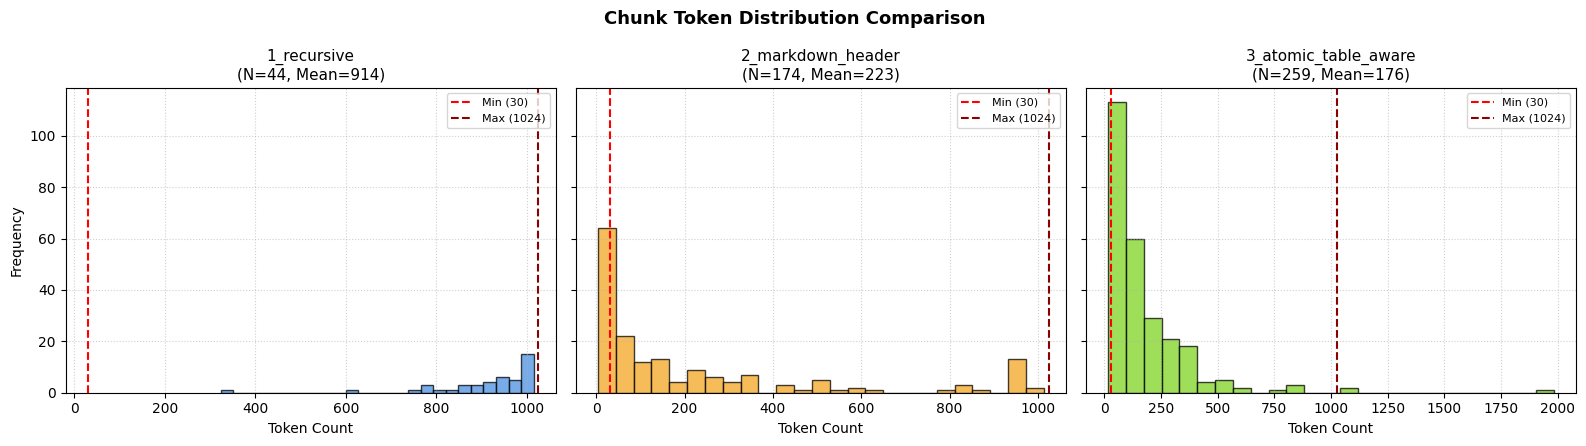

[SAVE] Diagnostic chart saved to: /content/drive/MyDrive/RAG_Atlas200DK/data/output/token_distribution_diagnostic.png


In [44]:
# ============================================================================
# Cell D.4 — Visual Diagnostic Dashboard
# ============================================================================

def plot_token_distribution_summary(comparison_results: dict):
    """
    Compute token metrics, display an ASCII histogram table,
    and optionally render a matplotlib distribution figure.
    """
    bins = [
        ("[0, 30)", 0, 30),
        ("[30, 256)", 30, 256),
        ("[256, 512)", 256, 512),
        ("[512, 1024)", 512, 1024),
        ("[1024+]", 1024, float("inf")),
    ]

    print("\n" + "=" * 88)
    print("TOKEN DISTRIBUTION METRICS & OUTLIER AUDIT")
    print("=" * 88)
    print(f"{'Strategy':<22} {'Count':>6} {'Min':>5} {'P25':>5} {'Median':>6} {'P75':>5} {'Max':>5} {'<30tok':>8} {'>1024tok':>9}")
    print("-" * 88)

    for name, data in comparison_results.items():
        chunks = data["chunks"]
        tokens = sorted([c["approx_tokens"] for c in chunks])
        if not tokens:
            continue
        n = len(tokens)
        p25 = tokens[int(n * 0.25)]
        p50 = tokens[int(n * 0.50)]
        p75 = tokens[int(n * 0.75)]
        t_min = tokens[0]
        t_max = tokens[-1]
        under_30 = sum(1 for t in tokens if t < 30)
        over_1024 = sum(1 for t in tokens if t > 1024)
        print(f"{name:<22} {n:>6} {t_min:>5} {p25:>5} {p50:>6} {p75:>5} {t_max:>5} {under_30:>8} {over_1024:>9}")
    print("=" * 88)

    # ASCII Bucket Breakdown
    print("\nTOKEN BUCKET HISTOGRAM (% of chunks):")
    print(f"{'Strategy':<22} " + " ".join(f"{b[0]:>11}" for b in bins))
    print("-" * 88)
    for name, data in comparison_results.items():
        tokens = [c["approx_tokens"] for c in data["chunks"]]
        n = len(tokens) if tokens else 1
        pcts = []
        for _, b_min, b_max in bins:
            count = sum(1 for t in tokens if b_min <= t < b_max)
            pcts.append(f"{count / n * 100:>10.1f}%")
        print(f"{name:<22} " + " ".join(pcts))
    print("=" * 88)

    # Matplotlib figure if available
    try:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
        colors = ["#4A90E2", "#F5A623", "#7ED321"]
        for ax, (name, data), col in zip(axes, comparison_results.items(), colors):
            tokens = [c["approx_tokens"] for c in data["chunks"]]
            ax.hist(tokens, bins=25, color=col, edgecolor="black", alpha=0.75)
            ax.axvline(30, color="red", linestyle="--", linewidth=1.5, label="Min (30)")
            ax.axvline(1024, color="darkred", linestyle="--", linewidth=1.5, label="Max (1024)")
            ax.set_title(f"{name}\n(N={len(tokens)}, Mean={data['token_mean']:.0f})", fontsize=11)
            ax.set_xlabel("Token Count", fontsize=10)
            ax.grid(True, linestyle=":", alpha=0.6)
            ax.legend(fontsize=8, loc="upper right")
        axes[0].set_ylabel("Frequency", fontsize=10)
        plt.suptitle("Chunk Token Distribution Comparison", fontsize=13, fontweight="bold")
        plt.tight_layout()
        out_fig = OUTPUT_DIR / "token_distribution_diagnostic.png"
        plt.savefig(out_fig, dpi=150)
        plt.show()
        print(f"[SAVE] Diagnostic chart saved to: {out_fig}")
    except Exception as e:
        print(f"[INFO] Matplotlib visualization skipped: {e}")


print("[OK] Visual diagnostic dashboard defined")

if "comparison_results" in dir() and comparison_results:
    plot_token_distribution_summary(comparison_results)

---
## Secao E: Processamento em Lote do Dataset e Serializacao de Artefatos

Com base nas auditorias da Secao D, a **Estrategia 3 (`3_atomic_table_aware`)** foi selecionada como a estrategia de producao definitiva por garantir:
1. **0% de fragmentacao em tabelas de hardware** (mantendo intactas matrizes de parametros do ATC e AIPP).
2. **0% de chunks orfaos** (injetando prefixos de breadcrumbs hierarquicos em todos os blocos de texto).
3. **Distribuicao controlada de tokens**, respeitando o teto de 1024 tokens para blocos de prosa.

Nesta secao, processamos todos os 10 manuais tecnicos da Huawei Ascend em `data/processed/markdown/`, validamos o esquema JSON padronizado e exportamos os artefatos finais nos formatos `.json`, `.jsonl` e `.parquet`, com empacotamento em `.zip` e suporte a sincronizacao com o Google Drive.

In [45]:
# ============================================================================
# Cell E.2 — Full Dataset Batch Chunking Pipeline
# ============================================================================

def batch_chunk_all_documents(
    md_dir: Path,
    strategy_func=strategy_atomic_table_aware,
    chunk_size: int = 1024,
    chunk_overlap: int = 64,
) -> list[dict]:
    """
    Process all Markdown manuals through the selected chunking strategy
    and assign standardized schema fields and deterministic chunk IDs.

    Returns:
        List of standardized chunk dicts conforming to production schema.
    """
    md_files = sorted(list(md_dir.glob("*.md")))
    if not md_files:
        raise FileNotFoundError(f"No Markdown files found in {md_dir}")

    print(f"[INFO] Processing {len(md_files)} manuals with strategy: {strategy_func.__name__}\n")
    all_chunks = []

    for md_path in tqdm(md_files, desc="Batch Chunking", unit="file"):
        doc_name = md_path.stem.strip()
        doc_slug = re.sub(r"[^\w\-.]", "_", doc_name).strip("_")
        text = md_path.read_text(encoding="utf-8")

        raw_chunks = strategy_func(
            text=text,
            doc_name=doc_name,
            max_chunk_tokens=chunk_size,
            chunk_overlap=chunk_overlap,
        )

        for idx, rc in enumerate(raw_chunks):
            meta = rc.get("metadata", {})
            header_path = meta.get("header_path", "Root")
            breadcrumb = f"[Doc: {doc_name} > Section: {header_path}]"

            standardized_chunk = {
                "chunk_id": f"{doc_slug}_{idx:04d}",
                "doc_name": doc_name,
                "breadcrumb": breadcrumb,
                "content": rc["text"],
                "approx_tokens": rc["approx_tokens"],
                "is_table": bool(meta.get("is_table", False)),
                "is_code_block": bool(meta.get("is_code_block", False)),
                "strategy": rc.get("strategy", "atomic_table_aware"),
            }
            all_chunks.append(standardized_chunk)

    print(f"\n[OK] Generated {len(all_chunks):,} total chunks across {len(md_files)} documents")
    return all_chunks


print("[OK] Batch chunking pipeline defined")

# Execute batch chunking over all 10 manuals
dataset_chunks = batch_chunk_all_documents(
    md_dir=PROCESSED_MD_DIR,
    strategy_func=strategy_atomic_table_aware,
    chunk_size=1024,
    chunk_overlap=64,
)

[OK] Batch chunking pipeline defined
[INFO] Processing 10 manuals with strategy: strategy_atomic_table_aware



Batch Chunking:   0%|          | 0/10 [00:00<?, ?file/s]


[OK] Generated 4,822 total chunks across 10 documents


In [46]:
# ============================================================================
# Cell E.3 — Schema Validation & Aggregate Summary Table
# ============================================================================

def validate_chunk_schema(chunks: list[dict]) -> tuple[bool, list[str]]:
    """
    Validate that every chunk conforms strictly to the standardized schema:
    {
      "chunk_id": str,
      "doc_name": str,
      "breadcrumb": str,
      "content": str,
      "approx_tokens": int,
      "is_table": bool,
      "is_code_block": bool,
      "strategy": str
    }

    Returns:
        (is_valid: bool, error_messages: list[str])
    """
    required_fields = {
        "chunk_id": str,
        "doc_name": str,
        "breadcrumb": str,
        "content": str,
        "approx_tokens": int,
        "is_table": bool,
        "is_code_block": bool,
        "strategy": str,
    }

    errors = []
    seen_ids = set()

    for idx, chunk in enumerate(chunks):
        for field, expected_type in required_fields.items():
            if field not in chunk:
                errors.append(f"Chunk #{idx} missing required field '{field}'")
            elif not isinstance(chunk[field], expected_type):
                errors.append(f"Chunk #{idx} field '{field}' has wrong type")

        cid = chunk.get("chunk_id", "")
        if cid in seen_ids:
            errors.append(f"Duplicate chunk_id: '{cid}' at index {idx}")
        seen_ids.add(cid)

        if not chunk.get("content", "").strip():
            errors.append(f"Chunk #{idx} ('{cid}') has empty content")

        if chunk.get("approx_tokens", 0) <= 0:
            errors.append(f"Chunk #{idx} ('{cid}') has non-positive tokens")

    return (len(errors) == 0, errors)


print("[OK] Schema validation function defined\n")

is_valid, validation_errors = validate_chunk_schema(dataset_chunks)
if not is_valid:
    print(f"[FAIL] Schema validation failed with {len(validation_errors)} errors:")
    for err in validation_errors[:10]:
        print(f"  - {err}")
    assert is_valid, "Dataset failed schema validation"
else:
    print(f"[OK] Schema validation PASSED for all {len(dataset_chunks):,} chunks")

# Aggregate Dataset Summary Table
doc_stats = defaultdict(lambda: {
    "chunks": 0, "tokens": 0, "tables": 0, "codes": 0, "token_list": []
})

for c in dataset_chunks:
    dn = c["doc_name"]
    doc_stats[dn]["chunks"] += 1
    doc_stats[dn]["tokens"] += c["approx_tokens"]
    doc_stats[dn]["token_list"].append(c["approx_tokens"])
    if c["is_table"]:
        doc_stats[dn]["tables"] += 1
    if c["is_code_block"]:
        doc_stats[dn]["codes"] += 1

print("\n" + "=" * 95)
print("DATASET AGGREGATE SUMMARY TABLE")
print("=" * 95)
print(f"{'Document Name':<42} {'Chunks':>7} {'Tokens':>10} {'Mean Tok':>9} {'Tables':>7} {'Code':>6}")
print("-" * 95)

total_chunks = len(dataset_chunks)
total_tokens = sum(c["approx_tokens"] for c in dataset_chunks)
total_tables = sum(1 for c in dataset_chunks if c["is_table"])
total_codes = sum(1 for c in dataset_chunks if c["is_code_block"])

for dn, s in sorted(doc_stats.items()):
    mean_tok = s["tokens"] / s["chunks"] if s["chunks"] else 0
    short_name = (dn[:39] + "...") if len(dn) > 42 else dn
    print(f"{short_name:<42} {s['chunks']:>7} {s['tokens']:>10,} {mean_tok:>8.0f} {s['tables']:>7} {s['codes']:>6}")

print("=" * 95)
grand_mean = total_tokens / total_chunks if total_chunks else 0
print(f"{'TOTAL':<42} {total_chunks:>7,} {total_tokens:>10,} {grand_mean:>8.0f} {total_tables:>7} {total_codes:>6}")
print("=" * 95)

[OK] Schema validation function defined

[OK] Schema validation PASSED for all 4,822 chunks

DATASET AGGREGATE SUMMARY TABLE
Document Name                               Chunks     Tokens  Mean Tok  Tables   Code
-----------------------------------------------------------------------------------------------
ATCToolInstructions                            259     45,525      176      86      0
ApplicationDevelopmentGuide_MindStudio_        124     29,775      240      10      0
Atlas200AIAcceleratorModuleApplicationS...    2769    382,684      138     467      0
EnvironmentDeploymentGuide                     214     37,607      176      12      0
Huawei_Atlas_200_DK_developer_kit_Techn...      65      9,131      140      15      0
MindStudioInstallationGuideUbuntuX86           160     23,771      149      13      0
TBECustomOperatorDevelopmentGuide_CLI_         107     24,660      230      13      0
TensorFlowNetworkModelPortingandTrainin...     745    118,797      159     100      0
User

In [48]:
# ============================================================================
# Cell E.4 — Serialization & Final Dataset Artifact Export
# ============================================================================
import datetime

# Helper for exporting structured chunks dictionary
def export_chunks_to_json(results: dict, output_path: Path, doc_name: str) -> Path:
    """Export comparison strategy results to structured JSON."""
    export_data = {
        "doc_name": doc_name,
        "encoding": TIKTOKEN_ENCODING,
        "strategies": {},
    }
    for strategy_name, stats in results.items():
        export_data["strategies"][strategy_name] = {
            "summary": {k: v for k, v in stats.items() if k != "chunks"},
            "chunks": [
                {
                    "text": c["text"],
                    "approx_tokens": c["approx_tokens"],
                    "metadata": c.get("metadata", {}),
                }
                for c in stats["chunks"]
            ],
        }
    json_out = output_path / f"{doc_name}_chunks.json"
    json_out.write_text(json.dumps(export_data, ensure_ascii=False, indent=2), encoding="utf-8")
    return json_out


# 1. Export Full Master JSON
json_path = OUTPUT_DIR / "huawei_ascend_rag_chunks_atomic.json"
json_path.write_text(
    json.dumps(dataset_chunks, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(f"[SAVE] Exported JSON:   {json_path.name} ({json_path.stat().st_size / 1024:.0f} KB)")

# 2. Export Streaming JSONL
jsonl_path = OUTPUT_DIR / "huawei_ascend_rag_chunks_atomic.jsonl"
with open(jsonl_path, "w", encoding="utf-8") as f:
    for chunk in dataset_chunks:
        f.write(json.dumps(chunk, ensure_ascii=False) + "\n")
print(f"[SAVE] Exported JSONL:  {jsonl_path.name} ({jsonl_path.stat().st_size / 1024:.0f} KB)")

# 3. Export Columnar Parquet (if pandas/pyarrow available)
parquet_path = OUTPUT_DIR / "huawei_ascend_rag_chunks_atomic.parquet"
try:
    import pandas as pd
    df = pd.DataFrame(dataset_chunks)
    df.to_parquet(parquet_path, index=False)
    print(f"[SAVE] Exported Parquet: {parquet_path.name} ({parquet_path.stat().st_size / 1024:.0f} KB)")
except Exception as e:
    print(f"[INFO] Parquet export skipped (optional): {e}")

# 4. Export Metadata Summary
summary_data = {
    "dataset_name": "huawei_ascend_rag_atomic_dataset",
    "created_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "tokenizer": TIKTOKEN_ENCODING,
    "strategy": "atomic_table_aware",
    "chunk_size": 1024,
    "chunk_overlap": 64,
    "total_documents": len(doc_stats),
    "total_chunks": total_chunks,
    "total_tokens": total_tokens,
    "total_table_chunks": total_tables,
    "total_code_chunks": total_codes,
    "documents": {
        dn: {
            "chunks": s["chunks"],
            "tokens": s["tokens"],
            "tables": s["tables"],
            "codes": s["codes"],
        }
        for dn, s in sorted(doc_stats.items())
    },
}
summary_path = OUTPUT_DIR / "rag_chunks_summary.json"
summary_path.write_text(
    json.dumps(summary_data, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(f"[SAVE] Exported Metadata: {summary_path.name} ({summary_path.stat().st_size / 1024:.0f} KB)")

# 5. Package final dataset archive
print("\n" + "=" * 55)
print("Packaging Final RAG Dataset Archive...")
print("=" * 55)

try:
    export_artifact(OUTPUT_DIR, "final_rag_dataset.zip")
except Exception as e:
    if "are the same file" in str(e):
        print("[INFO] Artifact already stored directly in the destination folder. Skipping redundant copy.")
    else:
        raise e

print("\nFinal Output Artifacts in " + str(OUTPUT_DIR) + ":")
for fp in sorted(OUTPUT_DIR.iterdir()):
    if fp.is_file():
        print(f"  - {fp.name:<45} ({fp.stat().st_size / 1024:>8.1f} KB)")

[SAVE] Exported JSON:   huawei_ascend_rag_chunks_atomic.json (5329 KB)
[SAVE] Exported JSONL:  huawei_ascend_rag_chunks_atomic.jsonl (5145 KB)
[SAVE] Exported Parquet: huawei_ascend_rag_chunks_atomic.parquet (959 KB)
[SAVE] Exported Metadata: rag_chunks_summary.json (2 KB)

Packaging Final RAG Dataset Archive...
[SAVE] Created /content/drive/MyDrive/RAG_Atlas200DK/data/output/final_rag_dataset.zip (2559 KB)
[INFO] Artifact already stored directly in the destination folder. Skipping redundant copy.

Final Output Artifacts in /content/drive/MyDrive/RAG_Atlas200DK/data/output:
  - ATCToolInstructions_chunks.json               (   672.9 KB)
  - chunking_output.zip                           (     0.3 KB)
  - final_rag_dataset.zip                         (  2558.6 KB)
  - huawei_ascend_rag_chunks_atomic.json          (  5329.0 KB)
  - huawei_ascend_rag_chunks_atomic.jsonl         (  5145.4 KB)
  - huawei_ascend_rag_chunks_atomic.parquet       (   959.1 KB)
  - parameter_sweep.json           